In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import shap

import copy
import random

from sqlalchemy import create_engine
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import CSVLogger

C:\Users\graye\dev\python\fantasyBaseballPlayerData\player_projections\player_projections_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dbConnectionString = "sqlite:///C:/Users/graye/dev/python/fantasyBaseballPlayerData/updated_database/baseball_info.db"

engine = create_engine(dbConnectionString)

In [3]:
timeSeriesHittingQuery = "SELECT playerId,plateAppearances,atBats,runs,hits,singles,doubles,triples,homeRuns,rbis,sacHits,sacFlies,hitByPitch,walks,intentionalWalks,strikeOuts,stolenBases,caughtStealing,groundedIntoDoublePlays,catcherInterference,battingAverage,onBasePercentage,sluggingPercentage,onBasePlusSlugging FROM SeasonStatsHitting"

df = pd.read_sql(timeSeriesHittingQuery, engine)

In [4]:
df = df.sort_values(by='playerId')

In [5]:
#df.describe().transpose()

In [6]:
hasMultipleSeasons = df["playerId"].value_counts() > 1
df = df[df["playerId"].isin(hasMultipleSeasons[hasMultipleSeasons].index)]

In [7]:
hasZeroPlateAppearances = df[df["plateAppearances"] == 0]

In [8]:
len(hasZeroPlateAppearances)

374

In [9]:
df.head()

,playerId,plateAppearances,atBats,runs,hits,singles,doubles,triples,homeRuns,rbis,...,intentionalWalks,strikeOuts,stolenBases,caughtStealing,groundedIntoDoublePlays,catcherInterference,battingAverage,onBasePercentage,sluggingPercentage,onBasePlusSlugging
3396,405395,296,275,29,65,45,3,0,17,50,...,3,45,2,0,14,0,0.236364,0.283784,0.432727,0.716511
2308,405395,351,307,42,83,45,14,0,24,68,...,1,55,1,2,13,0,0.270358,0.344729,0.550489,0.895218
3352,408234,526,472,48,121,90,16,0,15,75,...,0,118,0,0,21,0,0.256356,0.315589,0.385593,0.701183
1680,408234,370,334,21,86,62,20,0,4,34,...,0,74,0,0,11,0,0.257485,0.321622,0.353293,0.674915
2564,408234,433,397,25,101,86,10,0,5,43,...,3,101,1,0,11,0,0.254408,0.304850,0.317380,0.622230


In [10]:
#df.loc[:, "runs"] = np.random.permutation(df["runs"].values)

In [11]:
df.head()

,playerId,plateAppearances,atBats,runs,hits,singles,doubles,triples,homeRuns,rbis,...,intentionalWalks,strikeOuts,stolenBases,caughtStealing,groundedIntoDoublePlays,catcherInterference,battingAverage,onBasePercentage,sluggingPercentage,onBasePlusSlugging
3396,405395,296,275,29,65,45,3,0,17,50,...,3,45,2,0,14,0,0.236364,0.283784,0.432727,0.716511
2308,405395,351,307,42,83,45,14,0,24,68,...,1,55,1,2,13,0,0.270358,0.344729,0.550489,0.895218
3352,408234,526,472,48,121,90,16,0,15,75,...,0,118,0,0,21,0,0.256356,0.315589,0.385593,0.701183
1680,408234,370,334,21,86,62,20,0,4,34,...,0,74,0,0,11,0,0.257485,0.321622,0.353293,0.674915
2564,408234,433,397,25,101,86,10,0,5,43,...,3,101,1,0,11,0,0.254408,0.304850,0.317380,0.622230


In [12]:
n = len(df)
#update indexes so that they dont split players between train and val, val and test

trainIndexStop = int(n*0.7)

dfRow = df.iloc[trainIndexStop]

playerId    = dfRow["playerId"]
curPlayerId = dfRow["playerId"]

while trainIndexStop < len(df) and curPlayerId == playerId:
    trainIndexStop += 1
    curPlayerId =  df.iloc[trainIndexStop]["playerId"]

valIndexStop = int(n*0.9)

dfRow = df.iloc[valIndexStop]

playerId    = dfRow["playerId"]
curPlayerId = dfRow["playerId"]

while valIndexStop < len(df) and curPlayerId == playerId:
    valIndexStop += 1
    curPlayerId =  df.iloc[valIndexStop]["playerId"]

train_df = df[0:trainIndexStop]
val_df   = df[trainIndexStop:valIndexStop]
test_df  = df[valIndexStop:]

num_features = df.shape[1]

In [13]:
numericTrainDf     = train_df.select_dtypes(include=np.number)
categoricalTrainDf = train_df.select_dtypes(exclude=np.number)

numericValDf       = val_df.select_dtypes(include=np.number)
categoricalValDf   = val_df.select_dtypes(exclude=np.number)

numericTestDf      = test_df.select_dtypes(include=np.number)
categoricalTestDf  = test_df.select_dtypes(exclude=np.number)

In [14]:
trainMean = numericTrainDf.mean()
trainStd  = numericTrainDf.std()

In [15]:
trainDfNormalized = (numericTrainDf - trainMean) / trainStd
valDfNormalized   = (numericValDf   - trainMean) / trainStd
testDfNormalized  = (numericTestDf  - trainMean) / trainStd

In [16]:
trainDfNormalized = pd.concat([categoricalTrainDf, trainDfNormalized], axis=1)
valDfNormalized   = pd.concat([categoricalValDf  , valDfNormalized]  , axis=1)
testDfNormalized  = pd.concat([categoricalTestDf , testDfNormalized] , axis=1)

C:\Users\graye\AppData\Local\Temp\ipykernel_7736\688142391.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _  = ax.set_xticklabels(numericDf.keys(), rotation=90)


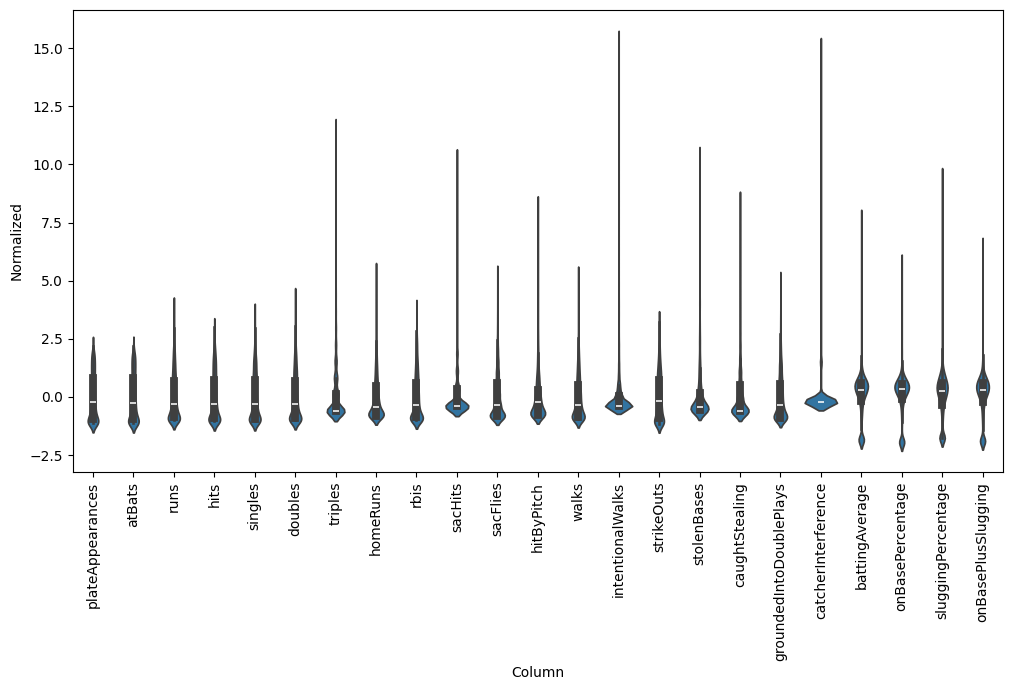

In [17]:
numericDf = df.select_dtypes(include=np.number)

dfStd = (numericDf - trainMean) / trainStd
dfStd = dfStd.melt(var_name='Column', value_name='Normalized')

plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=dfStd)
_  = ax.set_xticklabels(numericDf.keys(), rotation=90)

In [18]:
def getWindowedFeaturesAndLabels(frame, maxWindowSize):
    frameArray = frame.values.tolist()

    inputs = []
    labels = []
    
    r = 0

    curWindow = []

    playerId = frameArray[0][0]
    
    while r < len(frameArray):
        curPlayerId = frameArray[r][0]

        if curPlayerId != playerId:
            window = []
            
            windowR = 0

            while windowR <= len(curWindow):
                if len(window) == maxWindowSize or windowR == len(curWindow):
                    label = window.pop()

                    labelTest = copy.deepcopy(label)

                    relevantLabels = labelTest[3:4] + labelTest[8:10] + labelTest[16:17] + labelTest[23:]

                    if len(window) < maxWindowSize - 1:
                        diff = maxWindowSize - 1 - len(window)

                        while diff > 0:
                            padding = [0] * 24
                            window.append(padding)

                            diff -= 1

                    windowArray = [inner_list[1:] for inner_list in window]

                    inputs.append(copy.deepcopy(windowArray))
                    labels.append(copy.deepcopy(relevantLabels))

                    window.append(label)
                    window.pop(0)

                if windowR < len(curWindow):
                    window.append(curWindow[windowR])
                
                windowR += 1

            curWindow = []
            playerId  = curPlayerId

        curWindow.append(frameArray[r])

        r += 1

    return inputs,labels

In [19]:
trainFeatures,trainLabels = getWindowedFeaturesAndLabels(trainDfNormalized, 4)
valFeatures,valLabels     = getWindowedFeaturesAndLabels(valDfNormalized  , 4)
testFeatures,testLabels   = getWindowedFeaturesAndLabels(testDfNormalized , 4)

trainFeaturesArray = np.array(trainFeatures)
trainLabelsArray   = np.array(trainLabels  )

valFeaturesArray = np.array(valFeatures)
valLabelsArray   = np.array(valLabels  )

testFeaturesArray = np.array(testFeatures)
testLabelsArray   = np.array(testLabels  )

In [20]:
#l2/l1 regularization, dropout, activation function, optmizier, loss function, hidden units, hidden layers, batch size, batch normalization

def get_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(3, 23)),
        layers.Masking(mask_value=0., input_shape=(3, 23)),
        layers.LSTM(units= 15, dropout=0.5, recurrent_dropout=0.5, kernel_regularizer=regularizers.l2(0.001), return_sequences=False),
        layers.LayerNormalization(),
        layers.Dense(units = 5)
    ])

    return model

In [21]:
#for featureIndex in range(trainFeaturesArray.shape[2]):
#    shuffledTrainFeaturesArray = trainFeaturesArray.copy()
#
#    trainColumnElements = [shuffledTrainFeaturesArray[i][j][featureIndex] for i in range(len(shuffledTrainFeaturesArray)) for j in range(len(shuffledTrainFeaturesArray[i]))]
#
#    random.shuffle(trainColumnElements)
#    
#    k = 0
#    
#    for i in range(len(shuffledTrainFeaturesArray)):
#        for j in range(len(shuffledTrainFeaturesArray[i])):
#            shuffledTrainFeaturesArray[i][j][featureIndex] = trainColumnElements[k]
#    
#            k += 1
#
#    curModel = get_model()
#
#    curModel.compile(optimizer = tf.keras.optimizers.Adam(), loss="mse", metrics=[tf.keras.metrics.R2Score()])
#
#    csvFileName = './shuffled_training_permutations/' + str(featureIndex) + "_shuffled_training_log.csv"
#    
#    csvLogger = CSVLogger(csvFileName)
#
#    curModel.fit(trainFeaturesArray, trainLabelsArray, batch_size=32, epochs=50, validation_data=(valFeaturesArray, valLabelsArray), callbacks=[csvLogger])

In [22]:
curModel = get_model()

C:\Users\graye\dev\python\fantasyBaseballPlayerData\player_projections\player_projections_env\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
curModel.compile(optimizer = tf.keras.optimizers.Adam(), loss="mse", metrics=[tf.keras.metrics.R2Score()])

In [24]:
curModel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape               ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ masking (Masking)                   │ (None, 3, 23)              │              0 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ lstm (LSTM)                         │ (None, 15)                 │          2,340 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ layer_normalization                 │ (None, 15)                 │             30 │
│ (LayerNormalization)                │                            │                │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense (Dense)                       │ (None, 5)                  │             80 │
└─────────────────────────────────────┴────────────────────────────┴────────────────┘

 Total params: 2,450 (9.57 KB)

 Trainable params: 2,450 (9.57 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#callback = tf.keras.callbacks.EarlyStopping(patience=3)

In [26]:
csvLogger = CSVLogger('./shuffled_training_permutations/no_shuffle_training_log.csv')

In [27]:
#history =
curModel.fit(trainFeaturesArray, trainLabelsArray, batch_size=32, epochs=50, validation_data=(valFeaturesArray, valLabelsArray))#, callbacks=[csvLogger])

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 1.6226 - r2_score: -0.5709 - val_loss: 1.0289 - val_r2_score: -0.1560
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2199 - r2_score: -0.1734 - val_loss: 0.8840 - val_r2_score: 0.0110
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0326 - r2_score: 0.0103 - val_loss: 0.8249 - val_r2_score: 0.0782
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9193 - r2_score: 0.1218 - val_loss: 0.7744 - val_r2_score: 0.1371
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8485 - r2_score: 0.1907 - val_loss: 0.7536 - val_r2_score: 0.1619
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7821 - r2_score: 0.2560 - val_loss: 0.7328 - val_r2_score: 0.1855
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7632 - r2_score: 0.2741 - val_loss: 0.7187 - val_r2_score: 0.2017
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7189 - r2_score: 0.3177 - val_loss: 0.7077 - val_

In [28]:
explainer = shap.Explainer(curModel.predict, testFeaturesArray)

In [30]:
shap_values = explainer.shap_values(testFeaturesArray)

TypeError: 'numpy.ndarray' object is not callable

In [148]:
baselineTraining = pd.read_csv('./shuffled_training_permutations/no_shuffle_training_log.csv')

baselineTrainingLoss    = baselineTraining['loss'    ][49]
baselineTrainingValLoss = baselineTraining['val_loss'][49]

shuffledIndexToTrainingLossRatio = {}
shuffledIndexToValLossRatio      = {}

for featureIndex in range(trainFeaturesArray.shape[2]):
    csvFilePath = './shuffled_training_permutations/' + str(featureIndex) + '_shuffled_training_log.csv'

    shuffledTraining = pd.read_csv(csvFilePath)

    shuffledTrainingLoss    = shuffledTraining['loss'    ][49]
    shuffledTrainingValLoss = shuffledTraining['val_loss'][49]

    shuffledTrainingLossRatio = shuffledTrainingLoss / baselineTrainingLoss
    shuffledValLossRatio      = shuffledTrainingValLoss / baselineTrainingValLoss

    shuffledIndexToTrainingLossRatio[featureIndex] = shuffledTrainingLossRatio
    shuffledIndexToValLossRatio     [featureIndex] = shuffledValLossRatio

    print(str(featureIndex) + ", training loss ratio: " + str(shuffledTrainingLossRatio) + ", val loss ratio: " + str(shuffledValLossRatio))    

0, training loss ratio: 1.047854149457861, val loss ratio: 1.0377052893461634
1, training loss ratio: 1.052156213881297, val loss ratio: 1.0250213251647826
2, training loss ratio: 1.0114461315213685, val loss ratio: 1.0243400080645697
3, training loss ratio: 1.015699484597411, val loss ratio: 1.0008015198953257
4, training loss ratio: 1.0077497927027723, val loss ratio: 1.0163485877028007
5, training loss ratio: 1.029433344549121, val loss ratio: 1.0105803648885319
6, training loss ratio: 1.0532922842808847, val loss ratio: 1.0307768526293581
7, training loss ratio: 1.0480107564397314, val loss ratio: 1.0297612246538854
8, training loss ratio: 1.009791833274697, val loss ratio: 1.0236343078324062
9, training loss ratio: 1.0191909922002174, val loss ratio: 1.0206456613037882
10, training loss ratio: 1.0450534905394648, val loss ratio: 1.0183984836513116
11, training loss ratio: 1.0610158337452487, val loss ratio: 1.0135716310924832
12, training loss ratio: 1.05888933987478, val loss rat

In [ ]:
sorted_items_asc = sorted(my_dict.items(), key=lambda item: item[1])
sorted_dict_asc = dict(sorted_items_asc)

In [ ]:
history_shuffled = pd.read_csv('./shuffled_training_permutations/no_shuffle_training_log.csv')

In [ ]:
# Plot training & validation loss values
plt.plot(history_shuffled['loss'], label='Train Loss')
plt.plot(history_shuffled['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

In [134]:
testInput = np.array([testFeatures[1]])

testInput.shape

(1, 3, 23)

In [ ]:
curModel.predict(testInput)

In [ ]:
testInput

In [ ]:
trainDfNormalized.head(52)

In [ ]:
trainFeaturesArray[18]

In [ ]:
trainLabelsArray[17]